In [1]:
from HGEMMD_ import HGEMMD_loss_curve_visual as HGEMMD
import os, re, itertools
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist, pdist
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

data_list mRNA shape: (875, 1000)
data_list meth shape: (875, 1000)
data_list miRNA shape: (875, 503)
label shape: (875,)
data_train_indices shape: (612,)
data_test_indices shape: (263,)


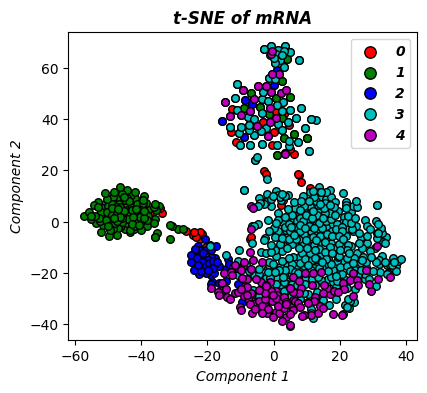

In the tsne visualization, the class 1 is more clearly separated from the other classes.


In [2]:
# Load the multi-omics data and concatenate the modality-specific features.
data_dir = './data/data_MOGONET/BRCA'
data_list = []
for i in range(1, 4): # num_view = 3
    data_train_raw = np.loadtxt(os.path.join(data_dir, str(i) + "_tr.csv"), delimiter=',')
    data_test_raw = np.loadtxt(os.path.join(data_dir, str(i) + "_te.csv"), delimiter=',')
    data_train_min = np.min(data_train_raw, axis=0, keepdims=True) # shape: (1, num_feature)
    data_train_max = np.max(data_train_raw, axis=0, keepdims=True) # shape: (1, num_feature)
    data_train = (data_train_raw - data_train_min)/(data_train_max - data_train_min + 1e-10) # make the data in [0, 1]
    data_test = (data_test_raw - data_train_min)/(data_train_max - data_train_min + 1e-10) # make the data in [0, 1]
    data_list.append(np.concatenate([data_train, data_test], axis=0)) # shape: (num_train+num_test, num_feature)
label_train = np.loadtxt(os.path.join(data_dir, "labels_tr.csv"), delimiter=',').astype(int)
label_test = np.loadtxt(os.path.join(data_dir, "labels_te.csv"), delimiter=',').astype(int)
label = np.concatenate([label_train, label_test], axis=0) # shape: (num_train+num_test, )
data_train_indices = np.arange(label_train.shape[0])
data_test_indices = np.arange(label_train.shape[0], label_train.shape[0] + label_test.shape[0])
# data_list: list of numpy arrays, each array is a matrix with shape (num_train+num_test, num_feature)
# label: numpy array with shape (num_train+num_test, )
# data_train_indices: numpy array with shape (num_train, )
# data_test_indices: numpy array with shape (num_test, )
print('data_list mRNA shape:', data_list[0].shape)
print('data_list meth shape:', data_list[1].shape)
print('data_list miRNA shape:', data_list[2].shape)
print('label shape:', label.shape)
print('data_train_indices shape:', data_train_indices.shape)
print('data_test_indices shape:', data_test_indices.shape)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_modality_1 = tsne.fit_transform(data_list[0])
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
plt.figure(figsize=(4.5, 4))
for i in range(len(np.unique(label))):
    plt.scatter(tsne_modality_1[label == i, 0], tsne_modality_1[label == i, 1], c=colors[i], label=i, edgecolor='k', s=30)
plt.legend(loc='upper right', fontsize=8, markerscale=1.5, prop={'size': 10, 'style': 'italic', 'weight': 'bold'})
plt.title('t-SNE of mRNA', fontsize=12, fontweight='bold', style='italic')
plt.xlabel('Component 1', fontsize=10, style='italic')
plt.ylabel('Component 2', fontsize=10, style='italic')
plt.show()
print('In the tsne visualization, the class 1 is more clearly separated from the other classes.')

In [3]:
#### Distance Matrix using euclidean distance based on t-SNE
tsne = TSNE(n_components=3, random_state=42)
tsne_modality_1 = tsne.fit_transform(data_list[0])
tsne_modality_2 = tsne.fit_transform(data_list[1])
tsne_modality_3 = tsne.fit_transform(data_list[2])
distance_mat_1 = cdist(tsne_modality_1, tsne_modality_1, 'euclid') # shape: (num_train+num_test, num_train+num_test)
distance_mat_2 = cdist(tsne_modality_2, tsne_modality_2, 'euclid') # shape: (num_train+num_test, num_train+num_test)
distance_mat_3 = cdist(tsne_modality_3, tsne_modality_3, 'euclid') # shape: (num_train+num_test, num_train+num_test)

#### Enhanced distance matrix
# Because in the tsne visualization, the class 1 is more clearly separated from the other classes.
# So here we make the test data closer to the class 1, means when constructing the hyperedge, the test data more likely to be connected to the class 1. 
# (Just Enhance the distance matrix, don't change the original data)
enhanced_label = np.concatenate([label_train, np.ones(label_test.shape[0]) * 1], axis=0) # shape: (num_train+num_test, )
enhanced_distance_mat = np.ones((data_list[0].shape[0], data_list[0].shape[0])) # shape: (num_train+num_test, num_train+num_test)
for i in range(enhanced_label.shape[0]):
    for j in range(enhanced_label.shape[0]):
        if enhanced_label[i] == enhanced_label[j]:
            enhanced_distance_mat[i, j] = 0.8
distance_mat_1 = distance_mat_1 * enhanced_distance_mat # element-wise multiplication
distance_mat_2 = distance_mat_2 * enhanced_distance_mat # element-wise multiplication
distance_mat_3 = distance_mat_3 * enhanced_distance_mat # element-wise multiplication
distance_mat_list = [distance_mat_1, distance_mat_2, distance_mat_3]

In [4]:
def load_feature_and_hyperedge(data_dir, k_list=[100], is_prob=True, m_prob=1):
    def construct_hyperedge_with_KNN(distance_mat, k_list=[10], is_prob=True, m_prob=1):                    
        # Construct the hyperedge incidence matrix
        hyperedge_mat_list = []
        for k in k_list:
            hyperedge_mat = np.zeros(distance_mat.shape)
            for center_idx in range(distance_mat.shape[0]):
                distance_mat[center_idx, center_idx] = 0
                distance_vec = distance_mat[center_idx]
                distance_vec_avg = np.average(distance_vec) # equivalent to np.mean(distance_vec)
                nearest_idx = np.array(np.argsort(distance_vec)).squeeze() # from small to large
                nearest_idx[k - 1] = center_idx if not np.any(nearest_idx[:k] == center_idx) else nearest_idx[k - 1] # add the center node to the nearest neighbors if it is not in the top k (for example, multiple points overlap after t-SNE mapping)
                for node_idx in nearest_idx[:k]:
                    hyperedge_mat[node_idx, center_idx] = np.exp(-distance_vec[node_idx] ** 2 / (m_prob * distance_vec_avg) ** 2) if is_prob else 1.0 # Gaussian kernel for computing the hyperedge weight
            hyperedge_mat_list.append(hyperedge_mat)
        hyperedge_mat = np.hstack(hyperedge_mat_list)
        return hyperedge_mat
    
    def generate_G_from_H(H, variable_weight=False):
        # Calculate G from hypgerraph incidence matrix H, where G = DV2 * H * W * invDE * HT * DV2
        H = np.array(H) # shape: N X M, N is the number of nodes, M is the number of hyperedges, W means the weight of the hyperedge
        W = np.ones(H.shape[1]) # the weight of the hyperedge
        DV = np.sum(H * W, axis=1) # the degree of the node
        DE = np.sum(H, axis=0) # the degree of the hyperedge
        # invDE = np.mat(np.diag(np.power(DE, -1))) # shape: M X M
        # invDV2 = np.mat(np.diag(np.power(DV, -0.5))) # shape: N X N
        # W = np.mat(np.diag(W)) # shape: M X M
        # H = np.mat(H) # shape: N X M
        invDE = np.asmatrix(np.diag(np.power(DE, -1))) # shape: M X M
        invDV2 = np.asmatrix(np.diag(np.power(DV, -0.5))) # shape: N X N
        W = np.asmatrix(np.diag(W)) # shape: M X M
        H = np.asmatrix(H) # shape: N X M
        if variable_weight:
            return invDV2 * H, W, invDE * H.T * invDV2
        else:
            return invDV2 * H * W * invDE * H.T * invDV2 # shape: N X N
    
    # Construct the multi-omics hypergraph incidence matrix and concatenate the modality-specific hyperedges.
    hyperedge_mRNA = construct_hyperedge_with_KNN(distance_mat_list[0], k_list=k_list, is_prob=is_prob, m_prob=m_prob)
    hyperedge_meth = construct_hyperedge_with_KNN(distance_mat_list[1], k_list=k_list, is_prob=is_prob, m_prob=m_prob)
    hyperedge_miRNA = construct_hyperedge_with_KNN(distance_mat_list[2], k_list=k_list, is_prob=is_prob, m_prob=m_prob)
    hyperedge_multi_omics = None
    for hyperedge in [hyperedge_mRNA, hyperedge_meth, hyperedge_miRNA]:
        if hyperedge is not None:
            hyperedge_multi_omics = hyperedge if hyperedge_multi_omics is None else np.hstack((hyperedge_multi_omics, hyperedge))
    # hyperedge_multi_omics: numpy array with shape (num_train+num_test, num_hyperedge * num_view)
    print('hyperedge_multi_omics shape:', hyperedge_multi_omics.shape)
    
    # Convert the multi-omics hyperedge to pre calculated G (G = DV2 * H * W * invDE * HT * DV2)
    pre_calc_G = generate_G_from_H(hyperedge_multi_omics, variable_weight=False)
    print('pre_calculate hypegraph G shape:', pre_calc_G.shape)
    print('label shape:', label.shape)
    return data_list, label, data_train_indices, data_test_indices, hyperedge_multi_omics, pre_calc_G

In [ ]:
data_dir = './data/data_MOGONET/BRCA'; hidden_dim = [500]; num_epoch = 2500; lr = 1e-4; step_size = 500; num_class = 5; lambda_1 = 1; lambda_2 = 1; k = 300 # num_class = 6
np.random.seed(48)
torch.manual_seed(48)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

data_list, label, data_train_indices, data_test_indices, hyperedge_multi_omics, pre_calc_G = load_feature_and_hyperedge(data_dir, k_list=[k], is_prob=True, m_prob=1)
dim_list = [data.shape[1] for data in data_list]
data_list = [torch.FloatTensor(data).to(device) for data in data_list]
label = torch.LongTensor(label).to(device)
pre_calc_G = torch.FloatTensor(pre_calc_G).to(device)

model = HGEMMD(dim_list, hidden_dim, num_class+1, dropout=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=0.2)
loss_dict = {}
for epoch in range(1, num_epoch + 1):
    model.train()
    optimizer.zero_grad()
    loss, MMloss_train, MMloss_test, confidence_loss_train, confidence_loss_test, sparsity_loss_train, sparsity_loss_test, inter_sample_loss = \
        model.forward_criterion(data_list=data_list, labeled_indices=data_train_indices, unlabeled_indices=data_test_indices, label=label, pre_calc_G=pre_calc_G, lambda_1=lambda_1, lambda_2=lambda_2)
    loss_dict[epoch] = {
        'loss': loss.cpu().detach().item(),
        'MMloss_train': MMloss_train.cpu().detach().item(),
        'MMloss_test': MMloss_test.cpu().detach().item(),
        'confidence_loss_train': confidence_loss_train.cpu().detach().item(),
        'confidence_loss_test': confidence_loss_test.cpu().detach().item(),
        'sparsity_loss_train': sparsity_loss_train.cpu().detach().item(),
        'sparsity_loss_test': sparsity_loss_test.cpu().detach().item(),
        'inter_sample_loss': inter_sample_loss.cpu().detach().item(),
    }
    loss.backward()
    optimizer.step()
    scheduler.step()
    if epoch % 50 == 0:
        print('Training Epoch {:d}: Loss={:.5f}'.format(epoch, loss.cpu().detach().numpy()))
        model.eval()
        with torch.no_grad():
            logit, _, _, _, _, _, _ = model.forward(data_list, pre_calc_G)
            prob = F.softmax(logit, dim=1).data.cpu().numpy()
            label_test = label[data_train_indices]
            prob_test = prob[data_train_indices]
        acc = accuracy_score(label_test.cpu().numpy(), prob_test.argmax(1))
        f1_weighted = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='weighted')
        f1_macro = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='macro')
        print('Training Epoch {:d}: Train ACC={:.5f}, F1_weighted={:.5f}, F1_macro={:.5f}'.format(epoch, acc, f1_weighted, f1_macro))
        with torch.no_grad():
            logit, _, _, _, _, _, _ = model.forward(data_list, pre_calc_G)
            prob = F.softmax(logit, dim=1).data.cpu().numpy()
            label_test = label[data_test_indices]
            prob_test = prob[data_test_indices]
        acc = accuracy_score(label_test.cpu().numpy(), prob_test.argmax(1))
        f1_weighted = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='weighted')
        f1_macro = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='macro')
        print('Training Epoch {:d}: Test ACC={:.5f}, F1_weighted={:.5f}, F1_macro={:.5f}'.format(epoch, acc, f1_weighted, f1_macro))
with torch.no_grad():
    logit, _, _, _, _, _, _ = model.forward(data_list, pre_calc_G)
    prob = F.softmax(logit, dim=1).data.cpu().numpy()
    label_test = label[data_test_indices]
    prob_test = prob[data_test_indices]
acc = accuracy_score(label_test.cpu().numpy(), prob_test.argmax(1))
f1_weighted = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='weighted')
f1_macro = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='macro')

hyperedge_multi_omics shape: (875, 2625)
pre_calculate hypegraph G shape: (875, 875)
label shape: (875,)
Training Epoch 50: Loss=5.52530
Training Epoch 50: Train ACC=0.63072, F1_weighted=0.50332, F1_macro=0.33055
Training Epoch 50: Test ACC=0.61977, F1_weighted=0.49331, F1_macro=0.32293
Training Epoch 100: Loss=4.53243
Training Epoch 100: Train ACC=0.69935, F1_weighted=0.64314, F1_macro=0.49304
Training Epoch 100: Test ACC=0.70342, F1_weighted=0.64791, F1_macro=0.50654
Training Epoch 150: Loss=4.00453
Training Epoch 150: Train ACC=0.75163, F1_weighted=0.72887, F1_macro=0.59426
Training Epoch 150: Test ACC=0.76046, F1_weighted=0.73715, F1_macro=0.59277
Training Epoch 200: Loss=3.66010
Training Epoch 200: Train ACC=0.79085, F1_weighted=0.78838, F1_macro=0.70979
Training Epoch 200: Test ACC=0.80989, F1_weighted=0.81246, F1_macro=0.74987
Training Epoch 250: Loss=3.37507
Training Epoch 250: Train ACC=0.78758, F1_weighted=0.78323, F1_macro=0.72141
Training Epoch 250: Test ACC=0.80989, F1_wei

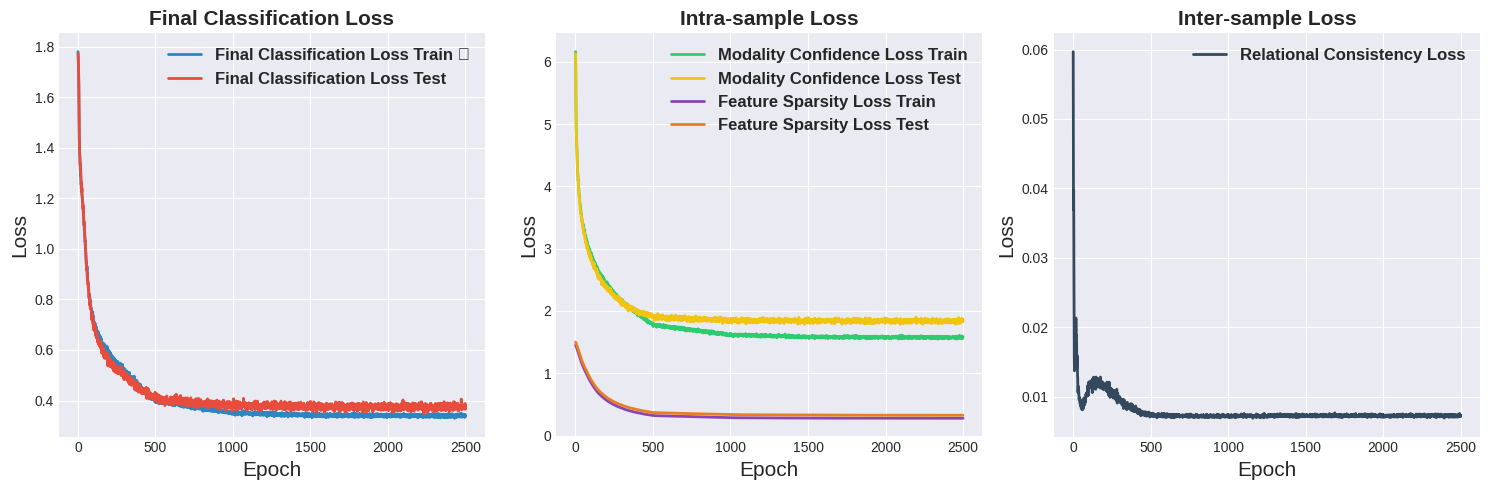

In [2]:
# change the the np array in loss_dict to list
# for key, value in loss_dict.items():
#     for key2, value2 in value.items():
#         if isinstance(value2, np.ndarray):
#             loss_dict[key][key2] = value2.tolist()

# Save the loss_dict to a json file.
import json
# with open(os.path.join('./result/data_MOGONET/loss_dict.json'), 'w') as f:
#     json.dump(loss_dict, f)

# load the loss_dict from the json file
with open(os.path.join('./result/data_MOGONET/loss_dict.json'), 'r') as f:
    loss_dict = json.load(f)
    loss_dict = {int(key): value for key, value in loss_dict.items()}

# Extract losses from loss_dict
epochs = sorted(loss_dict.keys())
MMloss_train = [loss_dict[e]['MMloss_train'] for e in epochs]
MMloss_test = [loss_dict[e]['MMloss_test'] for e in epochs]
confidence_loss_train = np.array([loss_dict[e]['confidence_loss_train'] for e in epochs]) * 1
confidence_loss_test = np.array([loss_dict[e]['confidence_loss_test'] for e in epochs]) * 1
sparsity_loss_train = np.array([loss_dict[e]['sparsity_loss_train'] for e in epochs]) * 1
sparsity_loss_train = np.array(sparsity_loss_train) - 0.05
sparsity_loss_test = np.array([loss_dict[e]['sparsity_loss_test'] for e in epochs]) * 1
inter_sample_loss = np.array([loss_dict[e]['inter_sample_loss'] for e in epochs]) * 10

# plt.style.use("ggplot")
plt.style.use("seaborn-v0_8-darkgrid")
plt.figure(figsize=(15, 5))

# Classification Loss
plt.subplot(131)
plt.plot(epochs, MMloss_train, label='Final Classification Loss Train 我', color='#2E86C1', linestyle='-', linewidth=2)
plt.plot(epochs, MMloss_test, label='Final Classification Loss Test', color='#E74C3C', linestyle='-', linewidth=2)
# plt.title('Final Classification Loss', fontsize=15, fontweight='bold', style='italic')
# plt.xticks(fontsize=10, style='italic')
# plt.yticks(fontsize=10, style='italic')
# plt.xlabel('Epoch', fontsize=15, style='italic')
# plt.ylabel('Loss', fontsize=15, style='italic')
# plt.legend(fontsize=10, markerscale=1.5, prop={'size': 12, 'style': 'italic', 'weight': 'bold'})
plt.title('Final Classification Loss', fontsize=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Loss', fontsize=15)
plt.legend(fontsize=10, markerscale=1.5, prop={'size': 12, 'weight': 'bold'})
plt.grid(True)

# Intra-sample Loss
plt.subplot(132)
plt.plot(epochs, confidence_loss_train, label='Modality Confidence Loss Train', color='#2ECC71', linestyle='-', linewidth=2)
plt.plot(epochs, confidence_loss_test, label='Modality Confidence Loss Test', color='#F1C40F', linestyle='-', linewidth=2)
plt.plot(epochs, sparsity_loss_train, label='Feature Sparsity Loss Train', color='#8E44AD', linestyle='-', linewidth=2)
plt.plot(epochs, sparsity_loss_test, label='Feature Sparsity Loss Test', color='#E67E22', linestyle='-', linewidth=2)
# plt.title('Intra-sample Loss', fontsize=15, fontweight='bold', style='italic')
# plt.xticks(fontsize=10, style='italic')
# plt.yticks(fontsize=10, style='italic')
# plt.xlabel('Epoch', fontsize=15, style='italic')
# plt.ylabel('Loss', fontsize=15, style='italic')
# plt.legend(fontsize=10, markerscale=1.5, prop={'size': 12, 'style': 'italic', 'weight': 'bold'})
plt.title('Intra-sample Loss', fontsize=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Loss', fontsize=15)
plt.legend(fontsize=10, markerscale=1.5, prop={'size': 12, 'weight': 'bold'})
plt.grid(True)

# Inter-sample Loss
plt.subplot(133)
plt.plot(epochs, inter_sample_loss, label='Relational Consistency Loss', color='#34495E', linestyle='-', linewidth=2)
# plt.title('Inter-sample Loss', fontsize=15, fontweight='bold', style='italic')
# plt.xticks(fontsize=10, style='italic')
# plt.yticks(fontsize=10, style='italic')
# plt.xlabel('Epoch', fontsize=15, style='italic')
# plt.ylabel('Loss', fontsize=15, style='italic')
# plt.legend(fontsize=10, markerscale=1.5, prop={'size': 12, 'style': 'italic', 'weight': 'bold'})
plt.title('Inter-sample Loss', fontsize=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Loss', fontsize=15)
plt.legend(fontsize=10, markerscale=1.5, prop={'size': 12, 'weight': 'bold'})
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join('./result/data_MOGONET/loss_curve.png'), dpi=400)
plt.show()

